In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('spam_Emails_data.csv')
df.head(5)

,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81271 entries, 0 to 81270
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   81271 non-null  object
 1   text    81270 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [5]:
df.describe()

,label,text
count,81271,81270
unique,2,81269
top,Ham,hi
freq,42717,2


In [7]:
print(df['label'].value_counts())

label
Ham     42717
Spam    38554
Name: count, dtype: int64


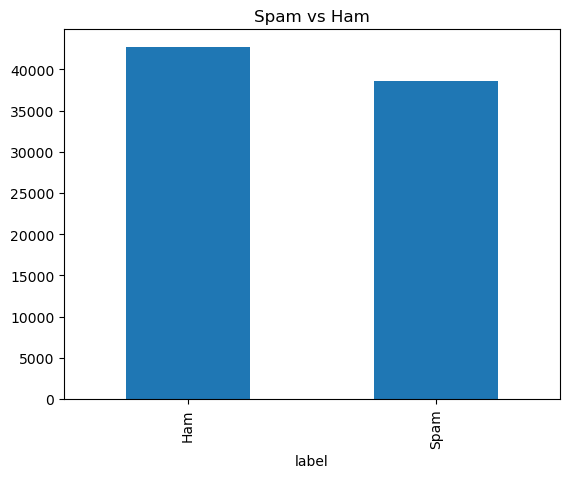

In [8]:
df['label'].value_counts().plot(kind = 'bar')
plt.title("Spam vs Ham")
plt.show()

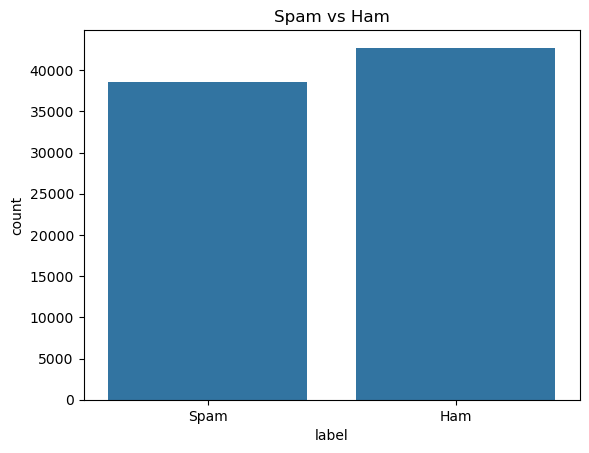

In [9]:
import seaborn as sns
sns.countplot(x = 'label',data = df)
plt.title("Spam vs Ham")
plt.show()

In [10]:
print(df['label'].unique())

['Spam' 'Ham']


In [11]:
df['label'] = df['label'].str.lower()

In [12]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [13]:
print(df['label'].isnull().sum())
print(df['label'].head(10))

0
0    1
1    0
2    1
3    1
4    0
5    1
6    0
7    0
8    0
9    0
Name: label, dtype: int64


In [14]:
df = df.dropna(subset=['label'])

In [17]:
print(df.shape)

(81271, 2)


In [20]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

df['text'] = df['text'].fillna("")

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]',' ',text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)
df['clean_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tanuj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
print(df['label'].unique())

[1 0]


In [23]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))  

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [25]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [27]:
print(df['label'].head(10))
print(df['label'].unique())

0    1
1    0
2    1
3    1
4    0
5    1
6    0
7    0
8    0
9    0
Name: label, dtype: int64
[1 0]


In [28]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

LinearSVC()

In [29]:
from sklearn.metrics import accuracy_score, classification_report

# Naive Bayes
y_pred_nb = nb.predict(X_test_tfidf)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

# Logistic Regression
y_pred_lr = lr.predict(X_test_tfidf)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# SVM
y_pred_svm = svm.predict(X_test_tfidf)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Naive Bayes Accuracy: 0.9320824361734851
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      8614
           1       0.94      0.91      0.93      7641

    accuracy                           0.93     16255
   macro avg       0.93      0.93      0.93     16255
weighted avg       0.93      0.93      0.93     16255

Logistic Regression Accuracy: 0.9686865579821593
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      8614
           1       0.96      0.97      0.97      7641

    accuracy                           0.97     16255
   macro avg       0.97      0.97      0.97     16255
weighted avg       0.97      0.97      0.97     16255

SVM Accuracy: 0.9715164564749308
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      8614
           1       0.96      0.98      0.97      7641

    accuracy                           0.97     16255
   ma

In [34]:
from sklearn.metrics import accuracy_score

models = {
    "Naive Bayes": nb,
    "Logistic Regression": lr,
    "SVM": svm
}

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc}")

Naive Bayes Accuracy: 0.9320824361734851
Logistic Regression Accuracy: 0.9686865579821593
SVM Accuracy: 0.9715164564749308


In [38]:
import pickle
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
pickle.dump(svm, open("svm_model.pkl", "wb"))
pickle.dump(lr, open("lr_model.pkl", "wb"))

In [63]:
def predict_email(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])
    
    pred = svm.predict(vector)[0]
    prob = lr.predict_proba(vector)[0]
    
    return {
        "prediction": "Spam" if pred == 1 else "Ham",
        "confidence": float(max(prob)),
        "spam_probability": float(prob[1]),
        "ham_probability": float(prob[0])
    }

In [83]:

    email_body = """We hope this message finds you well and excited for the festive season! On this occasion of Ugadi, ACE Engineering Academy is thrilled to announce Upto 30% OFF on all courses!

Ugadi marks new beginnings—and there’s no better time to start your success journey.

✨ Offer Highlights:

👉 Get UP TO 30% OFF on all courses!

📅 Offer valid only on March 19th & 20th


🎯 Courses available for: ESE | GATE | PSUs | SSC | RRB and many more!

✅ Classroom Coaching
✅ Online Live Classes
✅ Self-Paced Courses

"""

# Store it in a DataFrame
test_df = pd.DataFrame({"email": [email_body]})

In [85]:
test_df['result'] = test_df['email'].apply(predict_email)

for index, row in test_df.iterrows():
    print(f"--- Row {index} ---")
    print(f"Result: {row['result']}")
    print(f"Email Snippet: {row['email'][:50]}...")

--- Row 0 ---
Result: {'prediction': 'Spam', 'confidence': 0.818111654649399, 'spam_probability': 0.818111654649399, 'ham_probability': 0.18188834535060106}
Email Snippet: We hope this message finds you well and excited fo...
